In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer
using GeometryBasics, StaticArrays

atm_height   = 100_000.0     # atmosphere height (m)
L            = atm_height    # normalization length
N_layers     = 20            # atmospheric layers
width        = 100.0         # normalized width (wide domain ≈ 1D)
scale_height = 15_900.0      # density scale height (m)
T_sun        = 5800.0        # solar temperature (K)
q_solar      = 2 * 2600.0    # isotropic solar flux (both up and down) (W/m²)
κ_vis        = 0.01          # visible absorption coefficient
κ_ir         = 100.0         # infrared absorption coefficient
λ_min        = 1e-9          # minimum wavelength (m)
λ_max        = 1.0           # maximum wavelength (m)
stretch      = 5.0;          # spatial layer clustering near surface

In [3]:
# Log-spaced spatial layers: thin near the surface where temperature
# gradients are steepest, thick higher up where the atmosphere thins
layer_param      = range(0.0, 1.0, length = N_layers + 1)
layer_edges_norm = [(exp(stretch * t) - 1) / (exp(stretch) - 1) for t in layer_param]

# Solar volume: a thin layer at the top whose emission matches the desired
# irradiance. This avoids modifying the solver for spectral boundary fluxes.
sun_layer_height = 1000.0     # 1 km thick
κ_sun = q_solar * L / (4 * 5.670374419e-8 * T_sun^4 * sun_layer_height) # tuned absorption coefficient (emission)

normalized_scale_height = scale_height / L

# Reference spectrum (ρ = 1) on a fine wavelength grid
λ = 10 .^ range(log10(λ_min), log10(λ_max), length = 20_001)
κ_samples = [κ_vis + (κ_ir - κ_vis) / (1 + (4e-6 / x)^6) for x in λ]

ρ_top = exp(-1.0 / normalized_scale_height) # density at top
model = adaptiveSpectralBins(λ, κ_samples;
    tol         = 1e-3, # or 1e-4 for higher accuracy
    L_range     = (layer_edges_norm[2], 1.0),  # thinnest layer .. atmosphere height
    T_range     = (150.0, T_sun),
    scale_range = (ρ_top, 1.0))
n_bins = length(model.κ_ref) # number of spectral bins

15

In [4]:
faces     = PolyVolume2D{Float64}[]
divisions = Tuple{Int,Int}[]

for j in 1:N_layers
    y_bot = layer_edges_norm[j]
    y_top = layer_edges_norm[j + 1]
    y_mid = (y_bot + y_top) / 2

    verts = SVector(
        Point2(0.0, y_bot), Point2(width, y_bot),
        Point2(width, y_top), Point2(0.0, y_top)
    )
    solidwalls = SVector((j == 1), true, false, true) # transparent horizontal walls

    # Exponential density decay
    ρ = exp(-y_mid / normalized_scale_height)

    # Spectral absorption: sigmoid from visible-transparent to IR-opaque
    layer_κ = ρ .* model.κ_ref

    face = PolyVolume2D{Float64}(verts, solidwalls, n_bins, 1.0, 0.0)
    face.kappa_g   = layer_κ # local spectral absorption coefficients
    face.sigma_s_g = fill(0.0, n_bins) # local spectral scattering coefficients
    face.epsilon   = [fill(1.0, n_bins) for _ in 1:4]
    face.T_in_g    = -1.0       # solve for gas temperature
    face.q_in_g    = 0.0        # radiative equilibrium

    if j == 1
        face.T_in_w = [-1.0, 0.0, 0.0, 0.0]  # free surface, cold sides
    else
        face.T_in_w = [0.0, 0.0, 0.0, 0.0]   # cold boundaries
    end
    face.q_in_w = [0.0, 0.0, 0.0, 0.0] # source flux

    push!(faces, face)
    push!(divisions, (1, 2)) # each layer must be divided for the ray tracer to work
end

In [5]:
sun_h_norm = sun_layer_height / L
verts_sun  = SVector(
    Point2(0.0, 1.0), Point2(width, 1.0),
    Point2(width, 1.0 + sun_h_norm), Point2(0.0, 1.0 + sun_h_norm)
)

face_sun = PolyVolume2D{Float64}(
    verts_sun, SVector(false, true, true, true), n_bins, κ_sun, 0.0);
face_sun.kappa_g   = fill(κ_sun, n_bins) # spectrally uniform absorption coefficient
face_sun.sigma_s_g = fill(0.0, n_bins) # local spectral scattering coefficients
face_sun.epsilon   = [fill(1.0, n_bins) for _ in 1:4] # black space (fully absorbing)
face_sun.T_in_g    = T_sun # prescribed solar temperature
face_sun.q_in_g    = 0.0 # uses temperature
face_sun.T_in_w    = [0.0, 0.0, 0.0, 0.0] # cold space behind the sun (fully absorbing)
face_sun.q_in_w    = [0.0, 0.0, 0.0, 0.0] # uses temperature

push!(faces, face_sun)
push!(divisions, (1, 2)) # each layer must be divided for the ray tracer to work

mesh = RayTracingDomain2D(faces, divisions; verbose = false) # mesh the domain
mesh.spectral_model = model;                                 # spectral model

In [6]:
mesh(2*10^6; method = :exchange, verbose = false)
# smooth the ray tracing result to enforce energy conservation and reciprocity
# opt-in to pure Dykstra smoothing
smooth!(mesh; k_dykstra = 1000, verbose = false)
solveEquilibrium!(mesh, mesh.F_smooth;
    max_iters = 10_000, convergence_tol = 1e-14, verbose = false)

┌ Warning: Parallel-plate-like coupling detected in the traced exchange factors.
│ Pure alternating-projection smoothing predicted to converge at ρ ≈ 0.99589475.
│ Consider Dykstra smoothing if feasible: 'smooth!(mesh; k_dykstra=1000)',
│ or raise 'k_ap' to at least 31550 for AP to reach the target.
└ @ RayTraceHeatTransfer C:\Users\Nikolaj\.julia\packages\RayTraceHeatTransfer\tzEMT\src\RayTracing\RayTracing2D\ExchangeFactors2D\exchangeRayTracing.jl:22


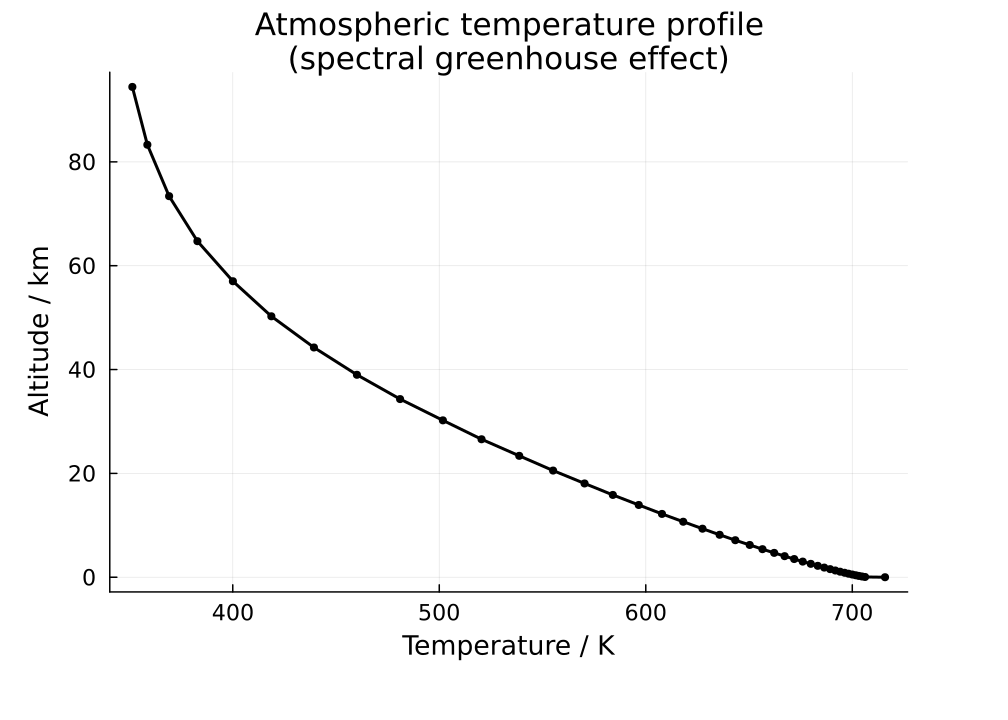

In [7]:
using Plots

gas_temps = Float64[]                                   # temperatures from the ground upwards [K]
altitudes = Float64[]                                   # matching altitudes [m]

# The ground is the bottom wall (wall 1) of the lowest cell of the lowest layer.
# Indexing: fine_mesh[layer][cell]; T_w[wall] is that wall's temperature from the solver.
push!(gas_temps, mesh.fine_mesh[1][1].T_w[1])
push!(altitudes, 0.0)

# Every layer was meshed into 2 cells stacked vertically (divisions (1, 2)): visit them from the bottom up.
for j in 1:N_layers                                     # atmospheric layers only; the solar layer on top is skipped
    for k in 1:2                                        # lower cell, then upper cell
        cell = mesh.fine_mesh[j][k]
        push!(gas_temps, cell.T_g)                      # T_g: gas temperature from the solver
        push!(altitudes, cell.midPoint[2] * L)          # cell-centre height: normalised y times the atmosphere height L
    end
end

Plots.plot(gas_temps, altitudes ./ 1000,
    linewidth = 2, color = :black, marker = :circle, markersize = 3,
    ylabel = "Altitude / km", xlabel = "Temperature / K",
    title = "Atmospheric temperature profile\n(spectral greenhouse effect)",
    legend = false, dpi = 150,
    guidefontsize = 12, tickfontsize = 10,
    left_margin = 5Plots.mm, bottom_margin = 10Plots.mm,
    right_margin = 15Plots.mm)